In [71]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import subprocess
import os

matplotlib.rcParams.update({"axes.grid": True, "font.size": 15})
# matplotlib.rcParams.keys()

In [72]:
def readmetadata(fname):
    on = False
    lines = ""
    with open(fname) as file:
        for line in file:
            idx = line.find("Hamiltonian")
            if idx != -1:
                on = True
            if on and line.find("--") == -1 and line.find("[") == -1:
                lines += line
            idx = line.find("Seed")
            if idx != -1:
                on = False
                break
    meta_dict = {"Description": lines}
    return meta_dict

def valErr_format(val, err):
    if err > 0:
        place = int(np.floor(np.log10(err)))
        
        # Handle the edge case where rounding bumps it to the next power of 10 (e.g., 0.98 -> 1.0)
        if round(err, -place) >= 10**(place + 1):
            place += 1    
        decimals = max(0, -place)
        err_rounded = round(err, -place)
        val_rounded = round(val, -place)
    else:
        decimals = 3  # Fallback if error is exactly 0
        err_rounded = 0.0
        val_rounded = val

    return f"{val_rounded:.{decimals}f} ± {err_rounded:.{decimals}f}"

nPreTrain = 38
nTrain = 200
final E = 3.069 ± 0.002
nPreTrain = 1000
nTrain = 3000
final E = 69.3 ± 0.2
nPreTrain = 1000
nTrain = 90
final E = 28.77 ± 0.02
nPreTrain = 1000
nTrain = 5118
final E = 9.831 ± 0.005
nPreTrain = 3000
nTrain = 1961
final E = 69.3 ± 0.1
nPreTrain = 2000
nTrain = 4000
final E = 58.09 ± 0.03
nPreTrain = 20
nTrain = 250
final E = 3.057 ± 0.003
nPreTrain = 375
nTrain = 0
final E = nan ± 0.000


/tmp/ipykernel_116686/1249546328.py:25: UserWarning: loadtxt: input contained no data: "./logs_NN/run_20260519_162215.csv"
  training = np.loadtxt(totfname, delimiter=',', skiprows=2+nPreTrain+3, max_rows=nTrain, usecols=range(4))


nPreTrain = 545
nTrain = 0
final E = nan ± 0.000


/tmp/ipykernel_116686/1249546328.py:25: UserWarning: loadtxt: input contained no data: "./logs_NN/run_20260518_180909.csv"
  training = np.loadtxt(totfname, delimiter=',', skiprows=2+nPreTrain+3, max_rows=nTrain, usecols=range(4))


nPreTrain = 38
nTrain = 250
final E = 3.036 ± 0.002
nPreTrain = 200
nTrain = 300
final E = 9.762 ± 0.004
nPreTrain = 73
nTrain = 1100
final E = 2.0067 ± 0.0004
nPreTrain = 3000
nTrain = 7083
final E = 58.15 ± 0.03
nPreTrain = 52
nTrain = 250
final E = 1.2 ± 0.2
nPreTrain = 746
nTrain = 0
final E = nan ± 0.000


...

nPreTrain = 454
nTrain = 0
final E = nan ± 0.000


/tmp/ipykernel_116686/1249546328.py:25: UserWarning: loadtxt: input contained no data: "./logs_NN/run_20260518_171602.csv"
  training = np.loadtxt(totfname, delimiter=',', skiprows=2+nPreTrain+3, max_rows=nTrain, usecols=range(4))


nPreTrain = 53
nTrain = 406
final E = 2.461 ± 0.002
nPreTrain = 89
nTrain = 200
final E = 3.15 ± 0.01
nPreTrain = 47
nTrain = 1100
final E = 2.0017 ± 0.0004


/tmp/ipykernel_116686/1249546328.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 6))


nPreTrain = 54
nTrain = 250
final E = 3.043 ± 0.002


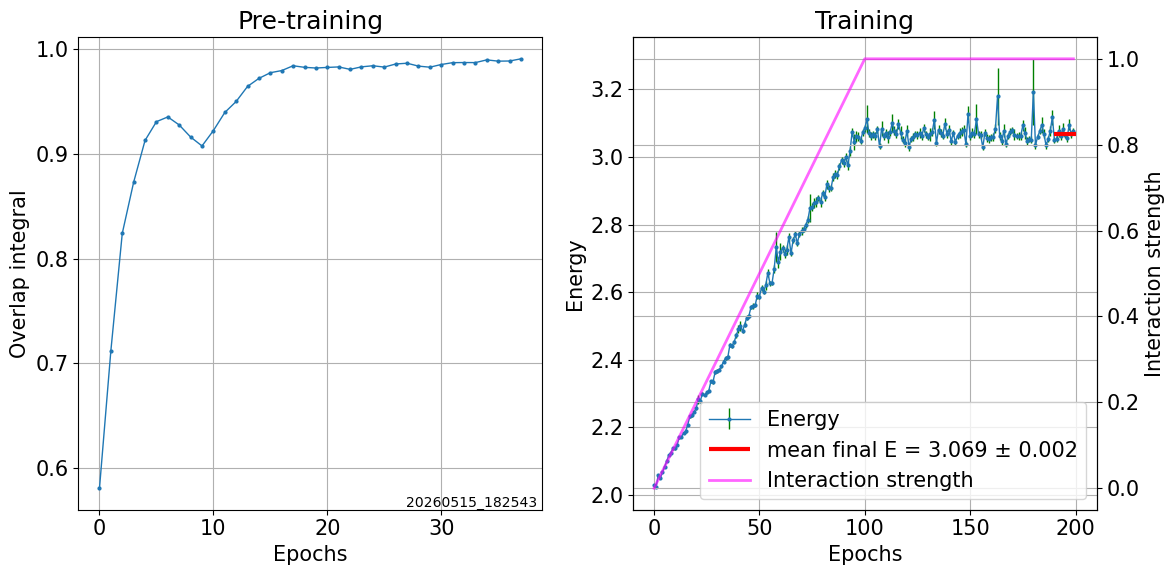

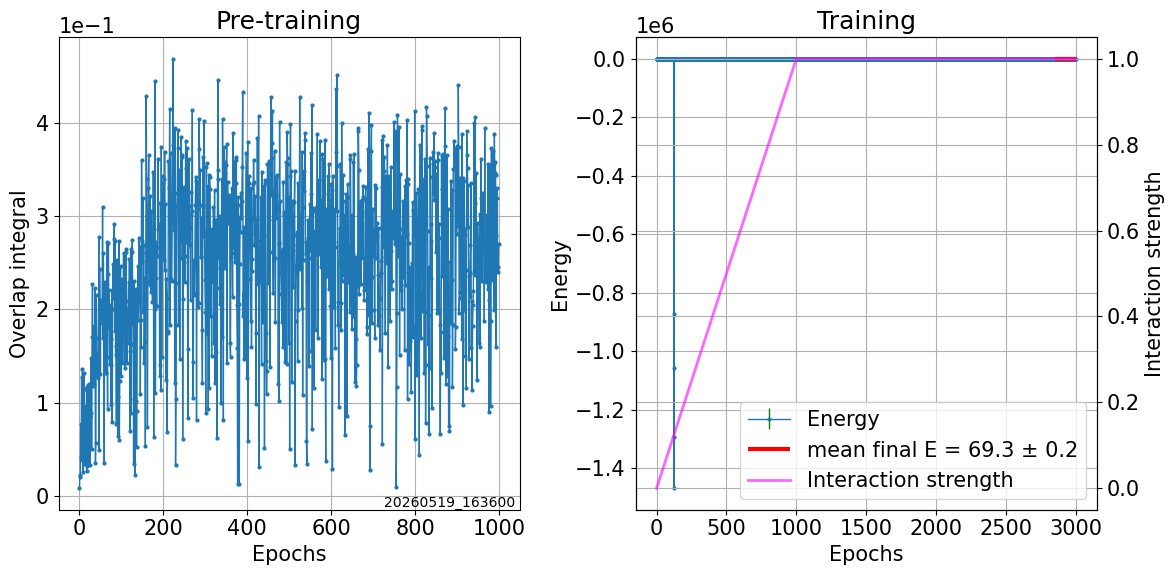

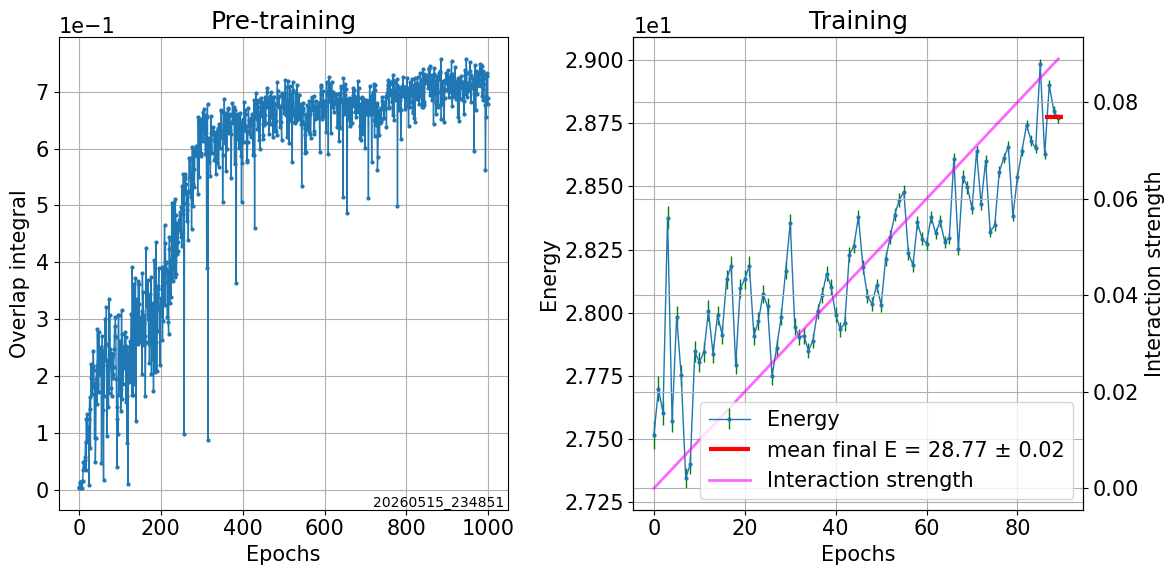

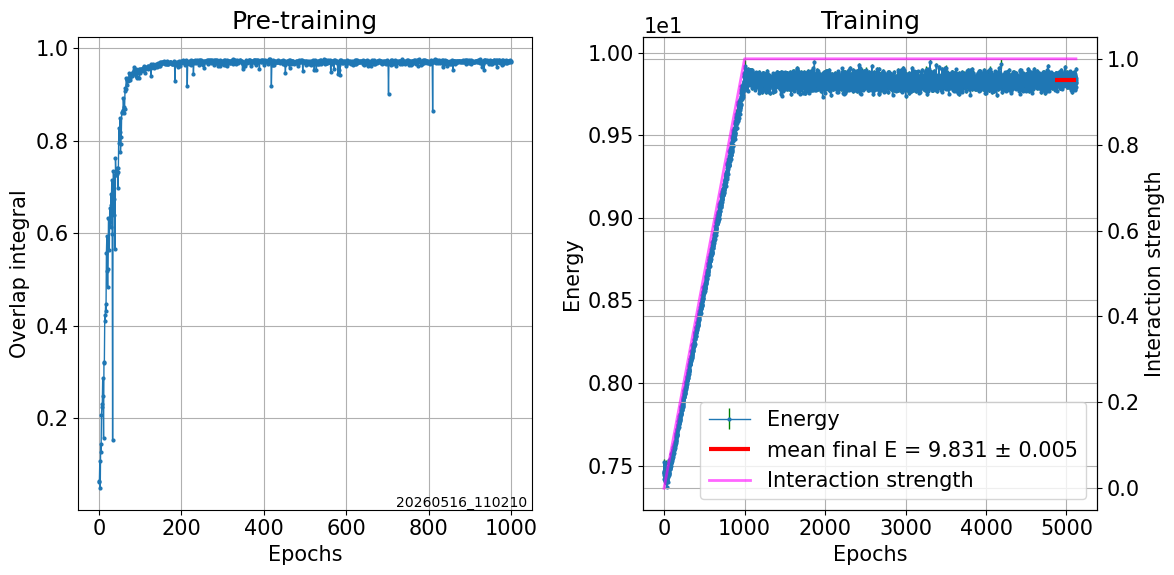

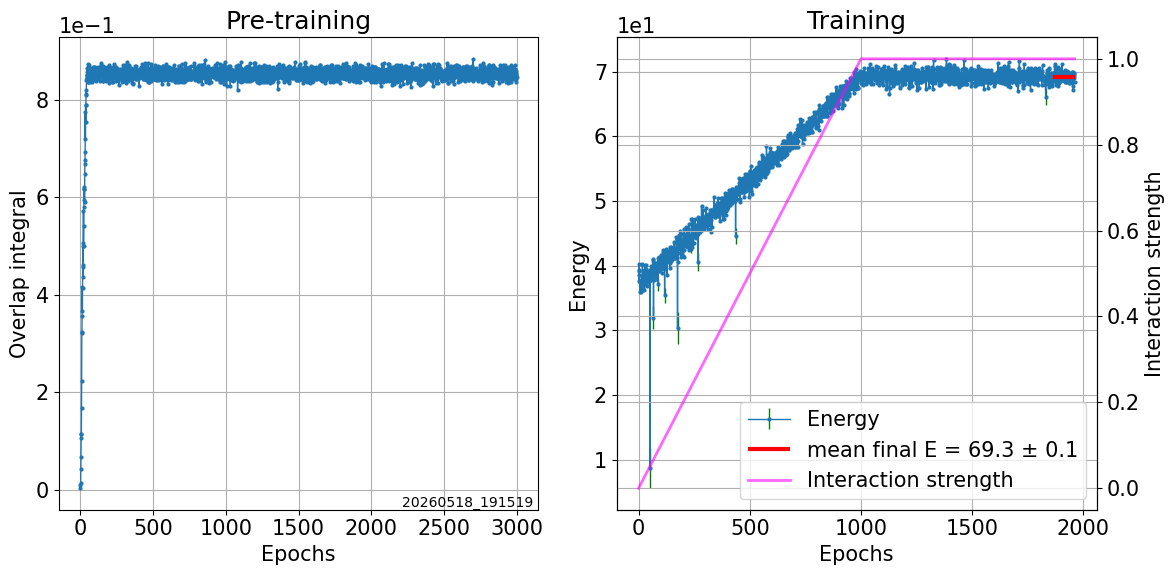

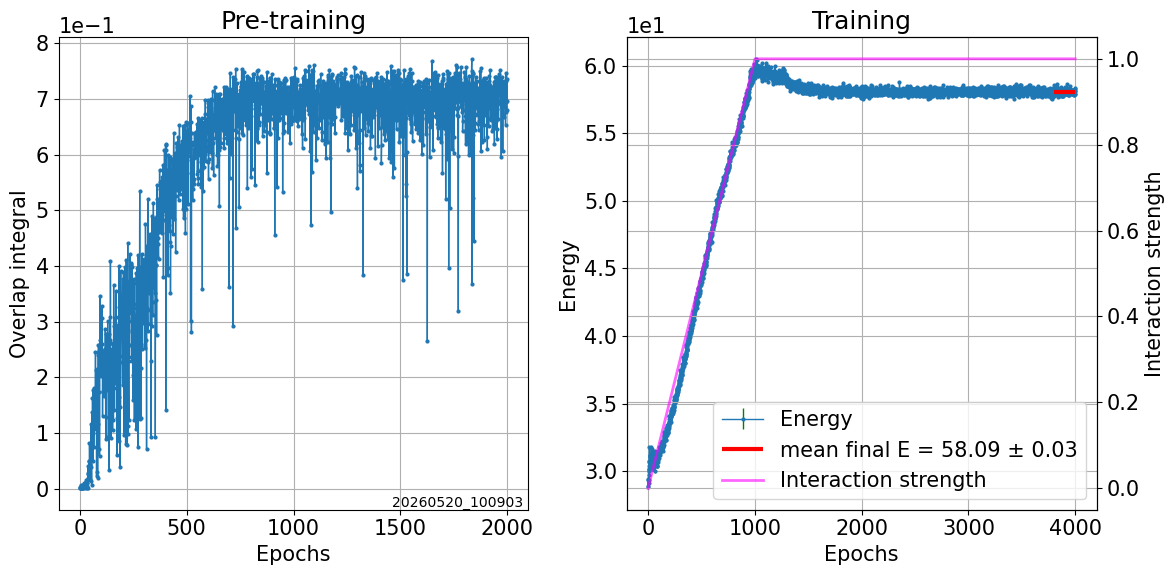

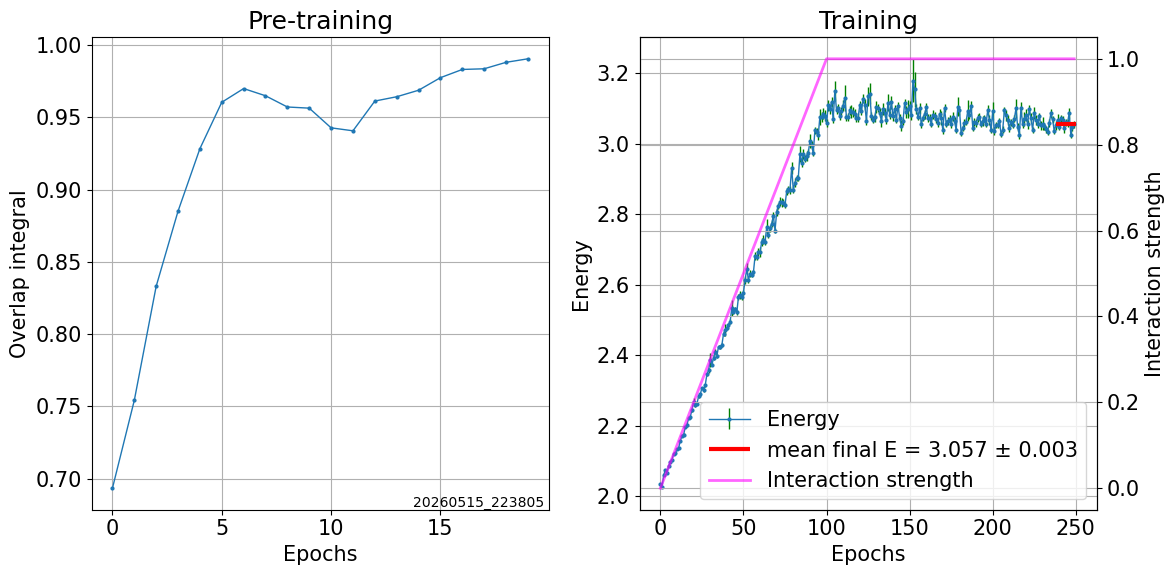

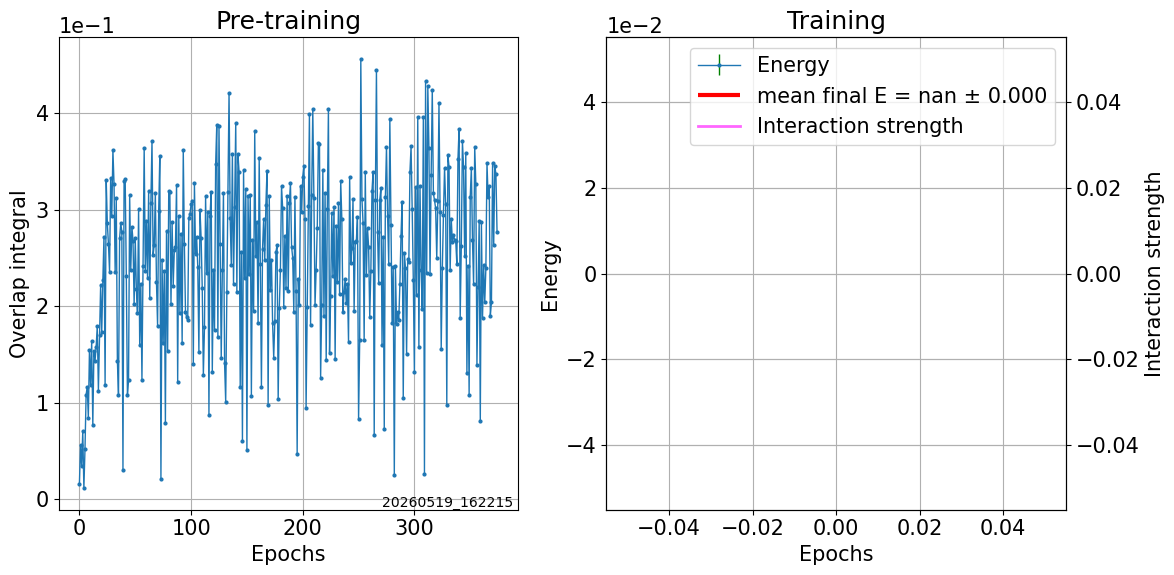

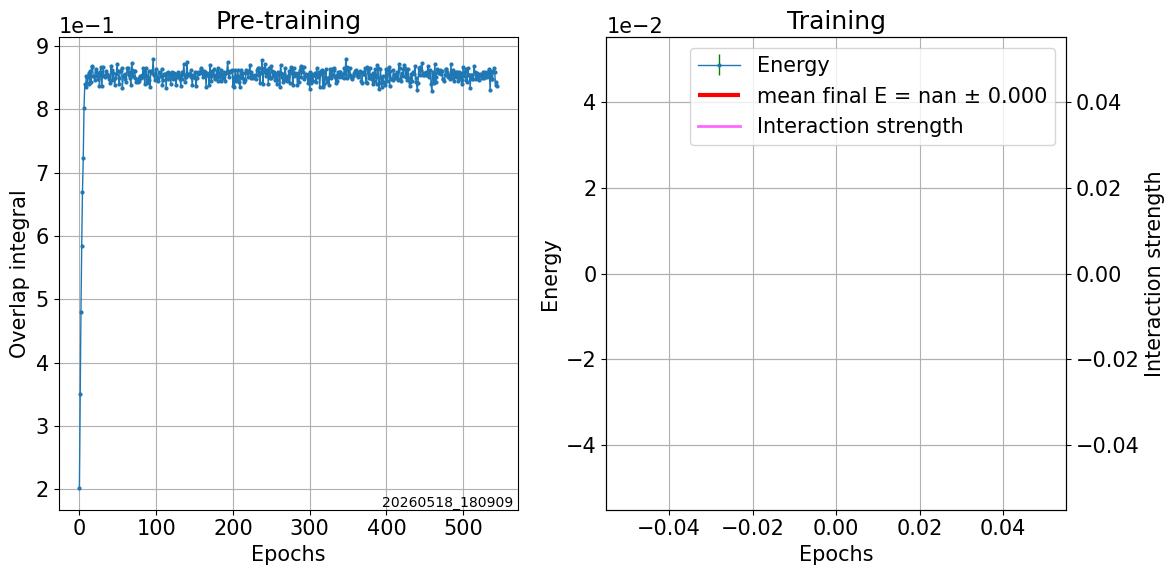

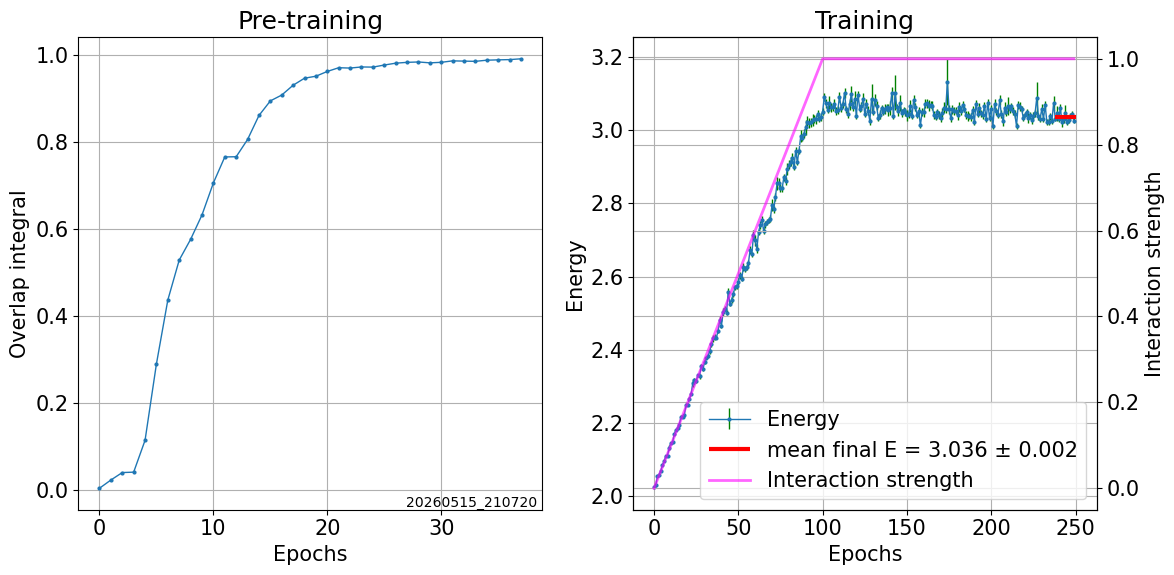

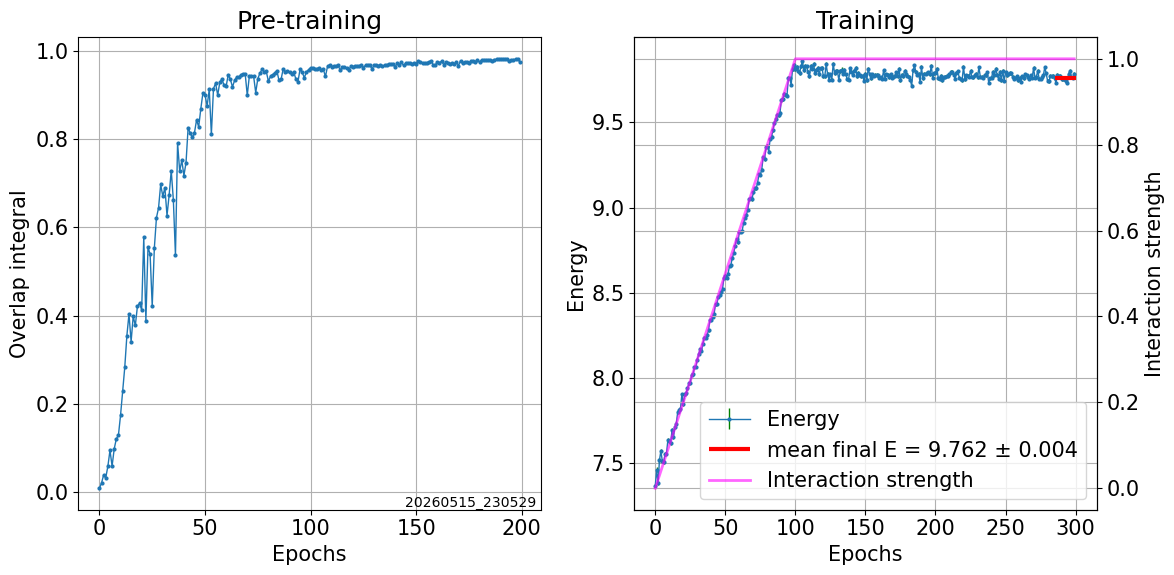

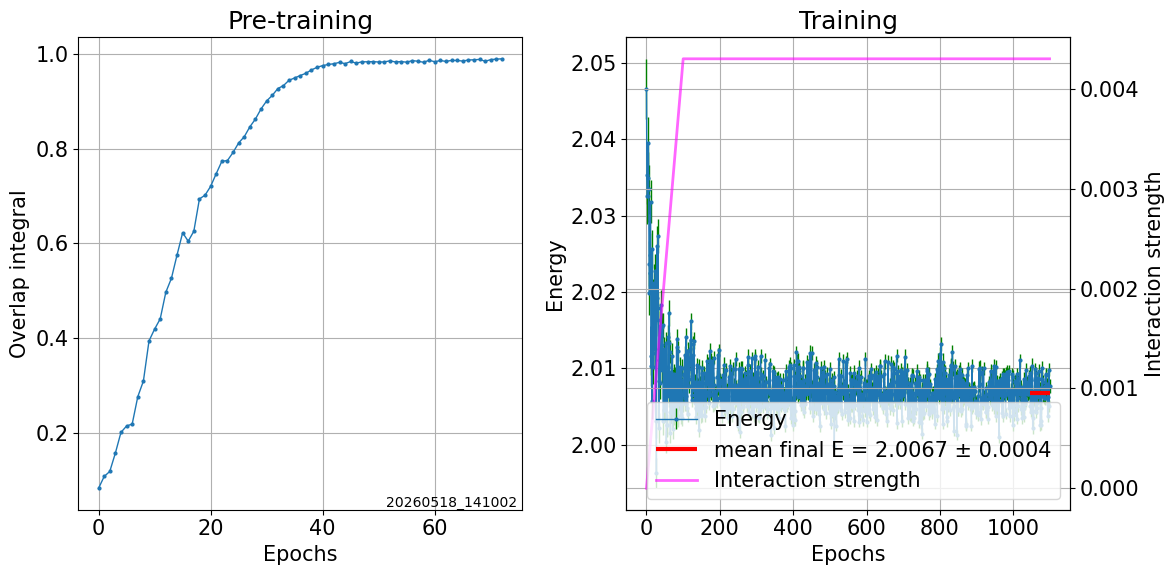

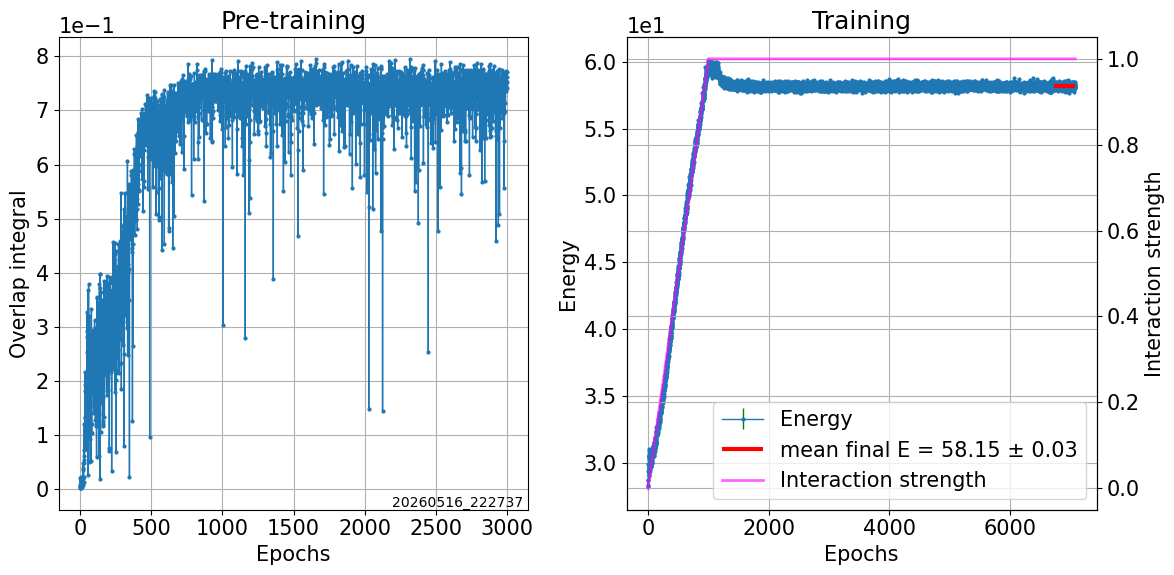

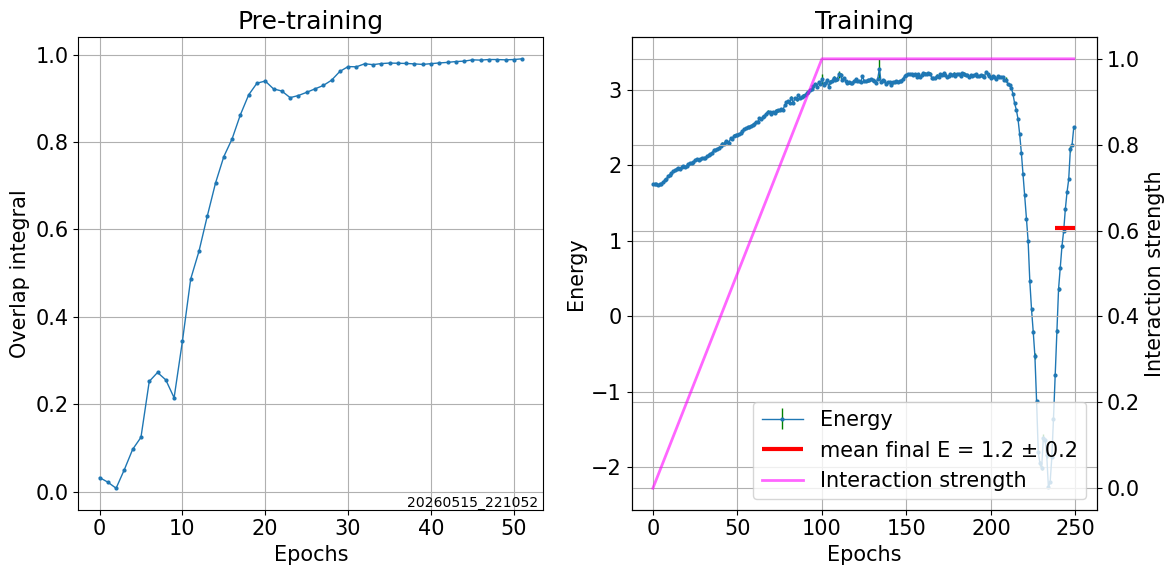

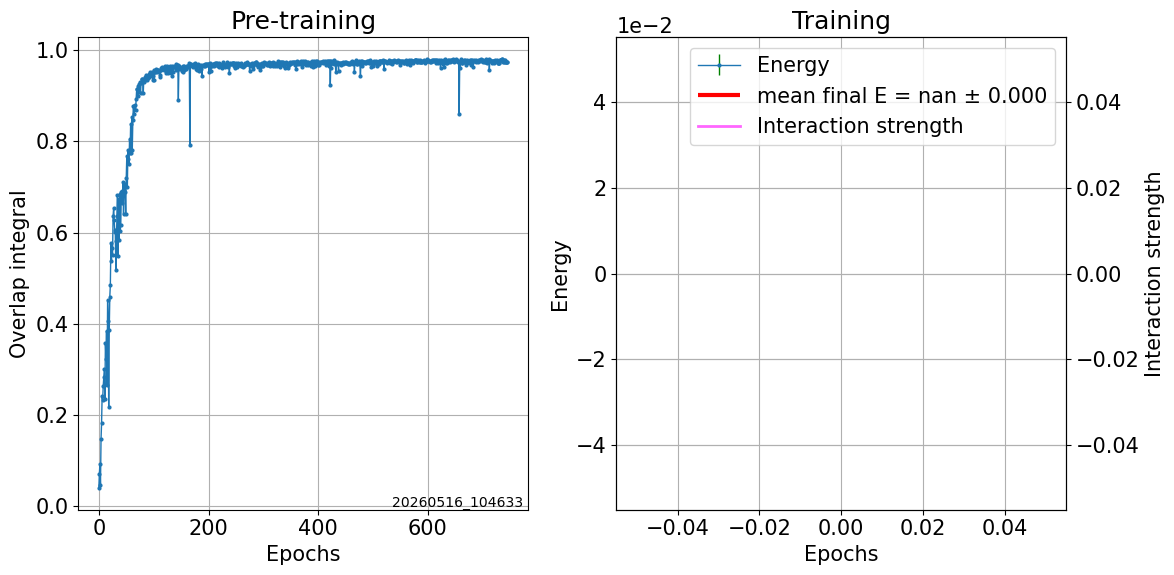

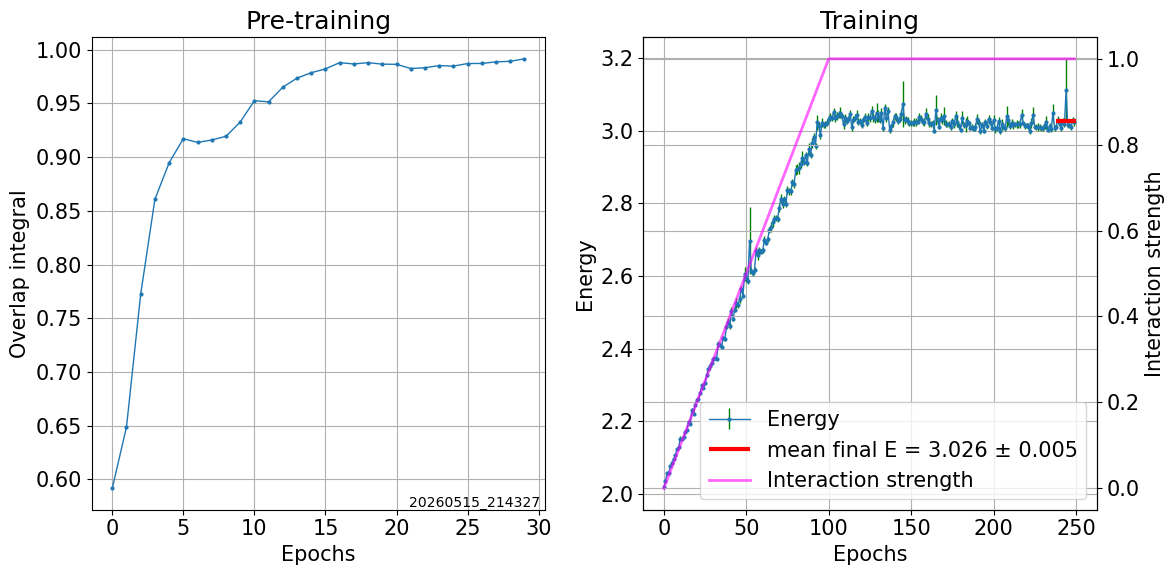

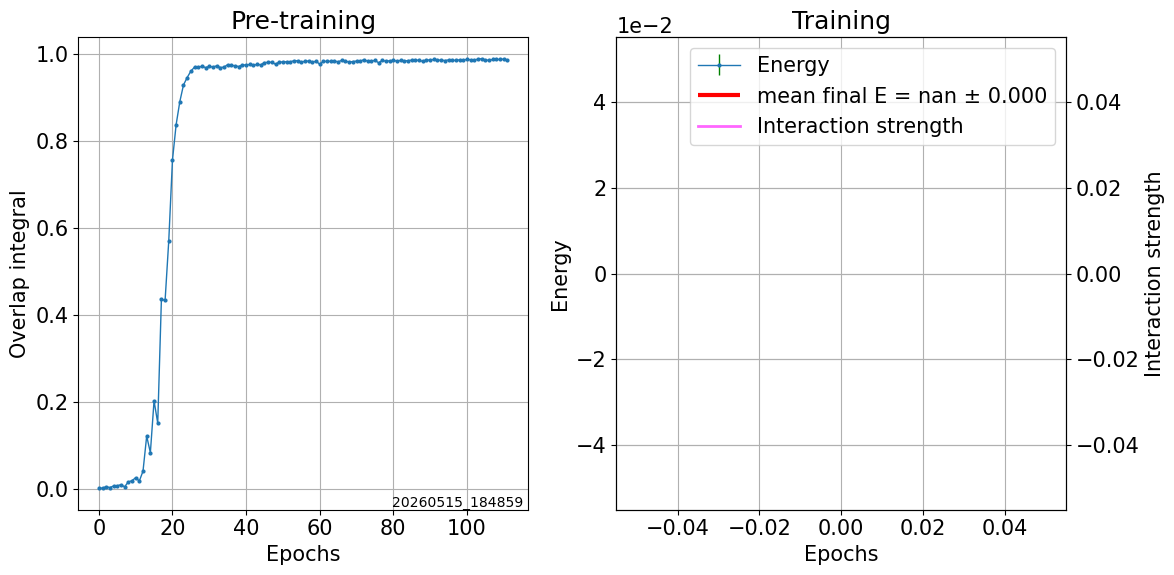

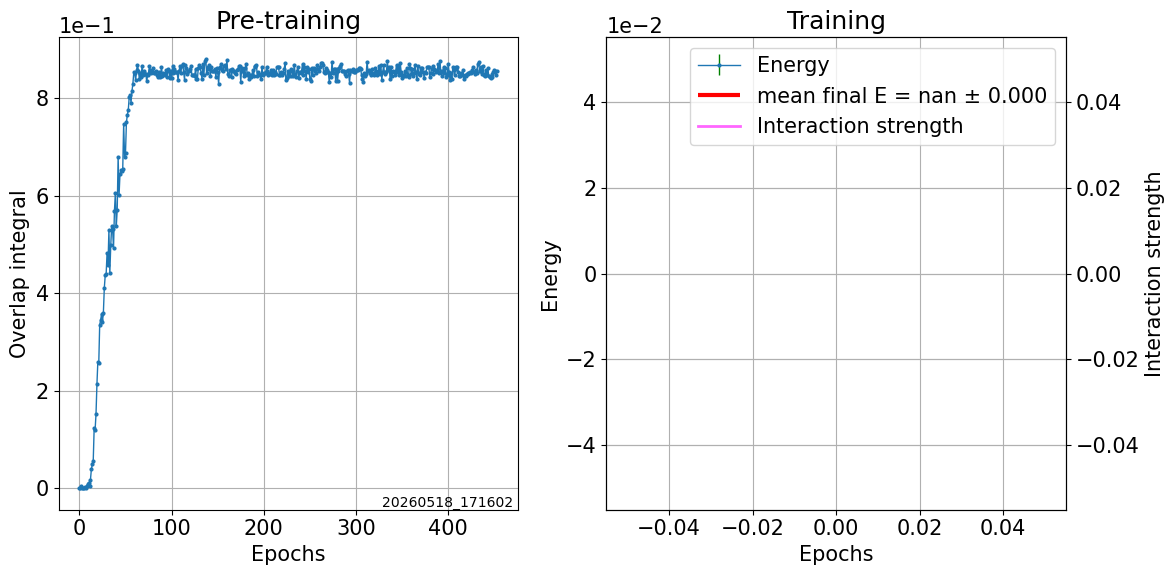

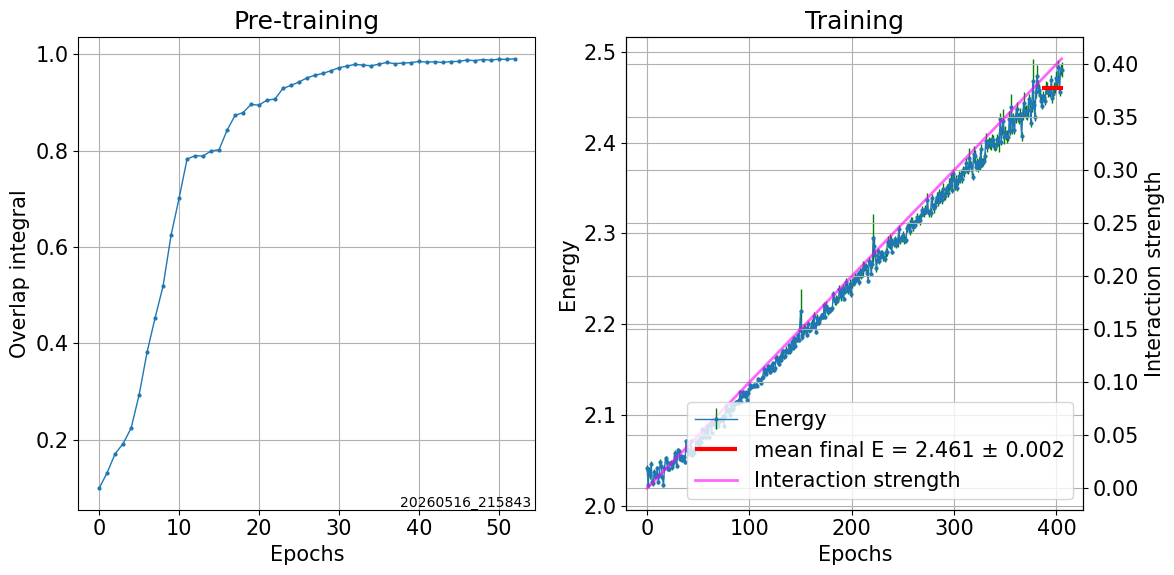

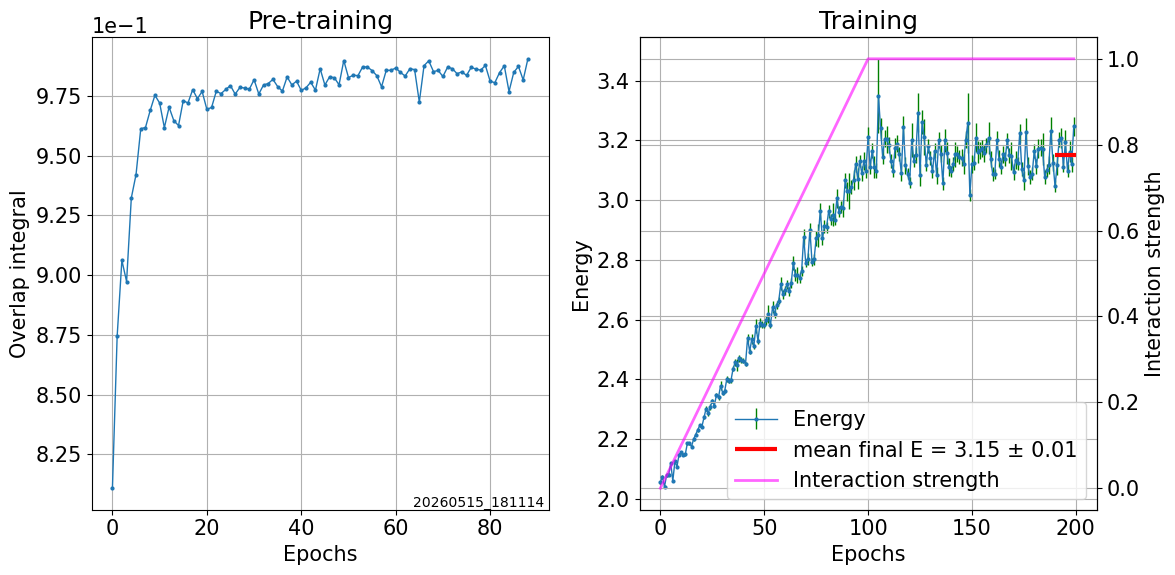

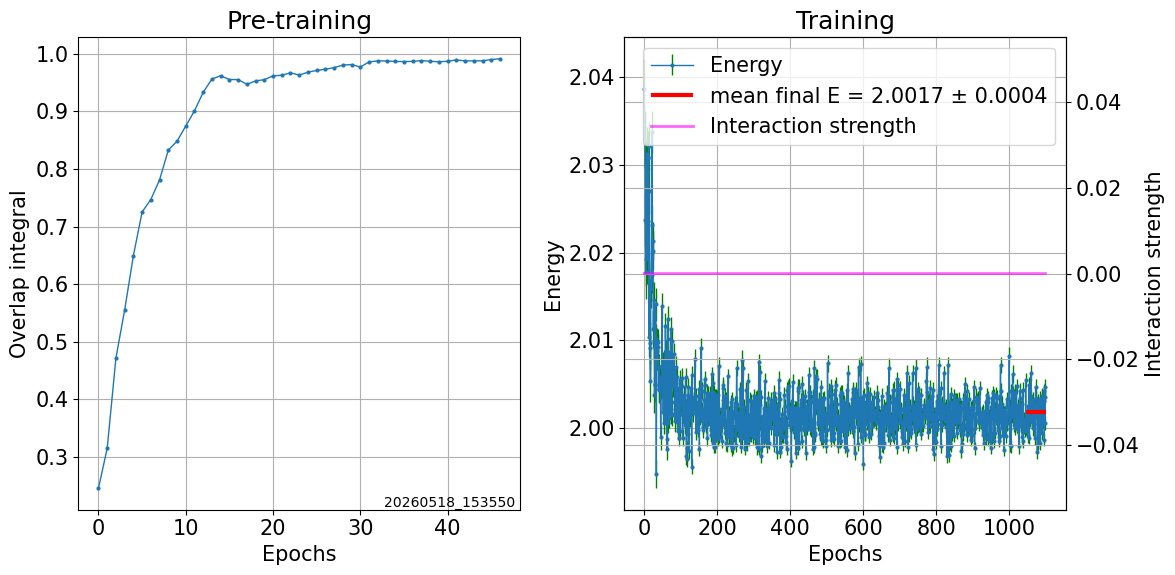

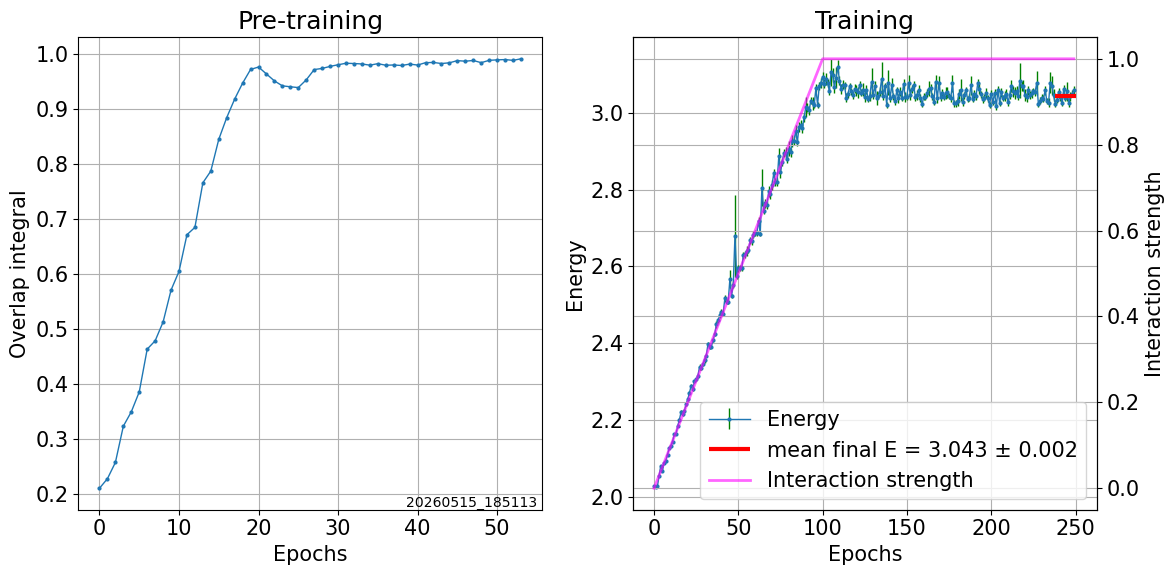

In [73]:
%matplotlib inline
fdir = "./logs_NN"
directory = os.fsencode(fdir)
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        fname = filename
        totfname = f"{fdir}/{fname}"
        nPreTrain = 0
        nTrain = 0
        sw = False
        with open(file=totfname) as logfile:
            for line in logfile:
                if len(line) > 1 and line[0] != '#':
                    if sw:
                        nTrain += 1
                    else:
                        nPreTrain += 1
                elif len(line) == 1:
                    sw = True
        print(f"nPreTrain = {nPreTrain}")
        print(f"nTrain = {nTrain}")
            
        K = np.loadtxt(totfname, delimiter=',', skiprows=2, max_rows=nPreTrain, usecols=0)
        training = np.loadtxt(totfname, delimiter=',', skiprows=2+nPreTrain+3, max_rows=nTrain, usecols=range(4))
        energy = training[:, 0]
        variance = training[:, 1]
        error = training[:, 2]
        strength = training[:, 3]
        numberofsubE = int(0.05 * nTrain)
        subE = energy[energy.size - numberofsubE:]
        meanE, dmeanE = np.mean(subE), np.std(subE) / np.sqrt(30)
        print(f"final E = {valErr_format(meanE, dmeanE)}")

        fig = plt.figure(figsize=(12, 6))
        gs = fig.add_gridspec(1, 2)

        ax = fig.add_subplot(gs[0, 0])
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.errorbar(np.arange(0, nPreTrain), K, ls='-', linewidth=1, marker='.', markersize=4, ecolor='black')
        ax.set_ylabel("Overlap integral")
        ax.set_xlabel("Epochs")
        ax.set_title("Pre-training")
        ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom")
        # ax.legend()

        ax = fig.add_subplot(gs[0, 1])
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.set_title("Training")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Energy") # Left y-axis label
        ax2 = ax.twinx()
        ax2.set_ylabel("Interaction strength")
        line1 = ax.errorbar(np.arange(0, nTrain), energy, error, ls='-', linewidth=1, marker='.', markersize=4, ecolor='green', label='Energy')
        finalE = ax.hlines(meanE, nTrain - subE.size, nTrain, ls='-', linewidth=3, color="red", label=f"mean final E = {valErr_format(meanE, dmeanE)}", zorder=3)
        line2 = ax2.errorbar(np.arange(0, nTrain), strength, ls='-', linewidth=2, color='magenta', alpha=0.6, label='Interaction strength')
        lines = [line1, finalE, line2]
        labels = [l.get_label() for l in lines]
        leg = ax2.legend(lines, labels, loc='best')
        leg.set_zorder(10)

        fig.tight_layout()
        # plt.show()
        fig.savefig(f"figs_NN/optimization_{fname[4:len(fname)-4]}.png", dpi=300, metadata=readmetadata(f"logs/{fname[:-4]}.log"))

{'Description': 'Hamiltonian      : CoulombHO\nWF Train Type    : EllipticGaussian\nWaveFunction     : NN_envelope\nSolver           : MetropolisHastings\npreferAnalytic   : false\nuseCache         : false\ndimensions (D)   : 3\nparticles (N)    : 10\nomega            : 1\nomega_z          : 2.8243\nrep_a_factor     : 0.0043\nrep_strength     : inf\nmaxStrength      : 1\ntime Step        : 0.15\nEquilibr. Steps  : 10000\nBFGS MC Steps    : 10000\nBFGS_tol         : 1e-05\nFinal MC Steps   : 2^16 (65536)\nNhid             : 12\nActivation Func  : tanh\nLearning Rate    : 0.5\nPretrain Steps   : 1000\nEnergy Steps     : 3000\nAdiab Steps      : 1000\nAdam_ktol        : 0.99\nmax_patience     : 80\nmin_improvement  : 0.02\nhelpDecay        : 0.4\n1bodyDens. Steps : 100000\n1bodyDens. rMax  : 3.5\n1bodyDens. nBins : 50\nSeed             : 0\n'}
{'Description': 'Hamiltonian      : CoulombHO\nWF Train Type    : EllipticGaussian\nWaveFunction     : NN_envelope\nSolver           : MetropolisHa

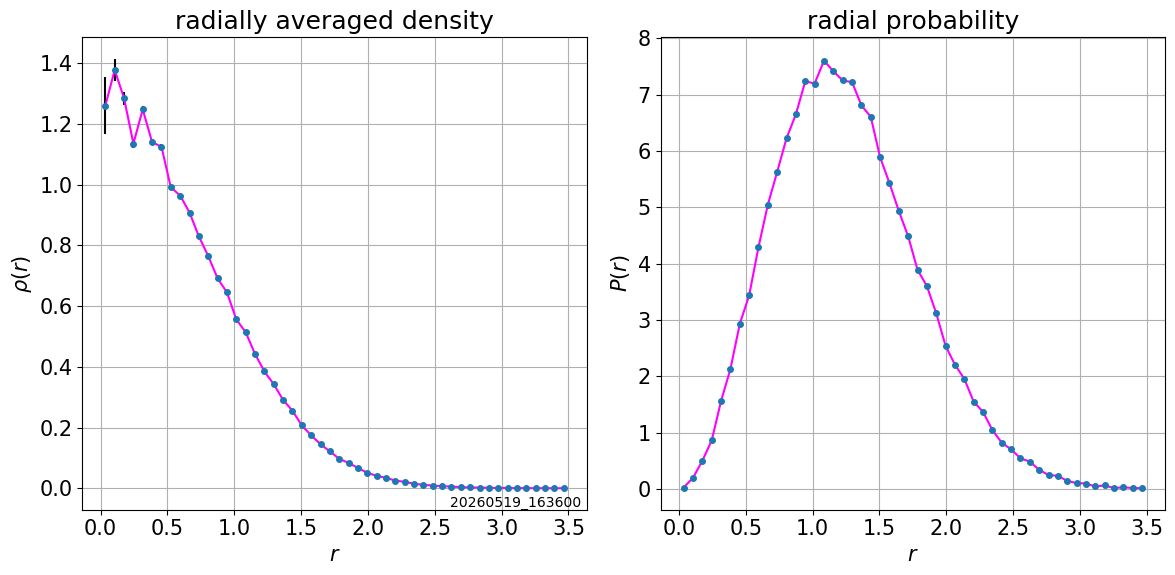

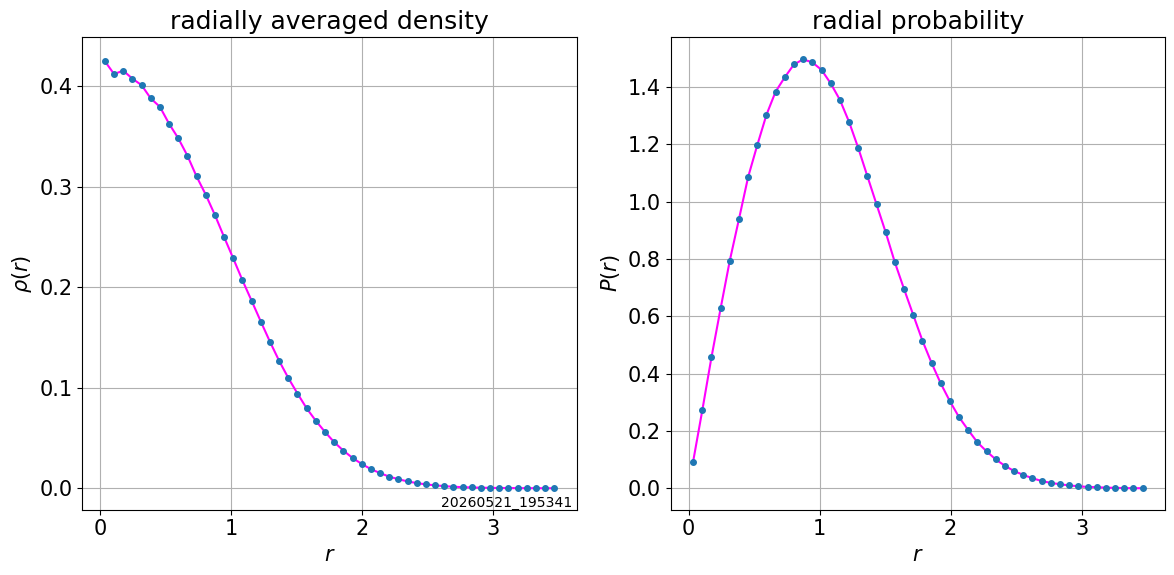

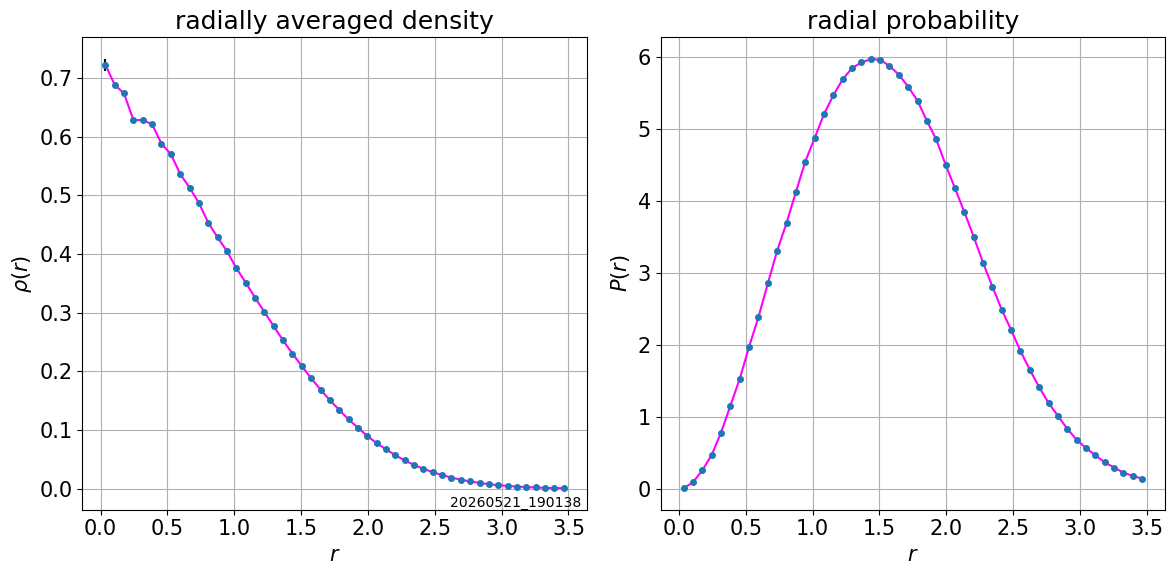

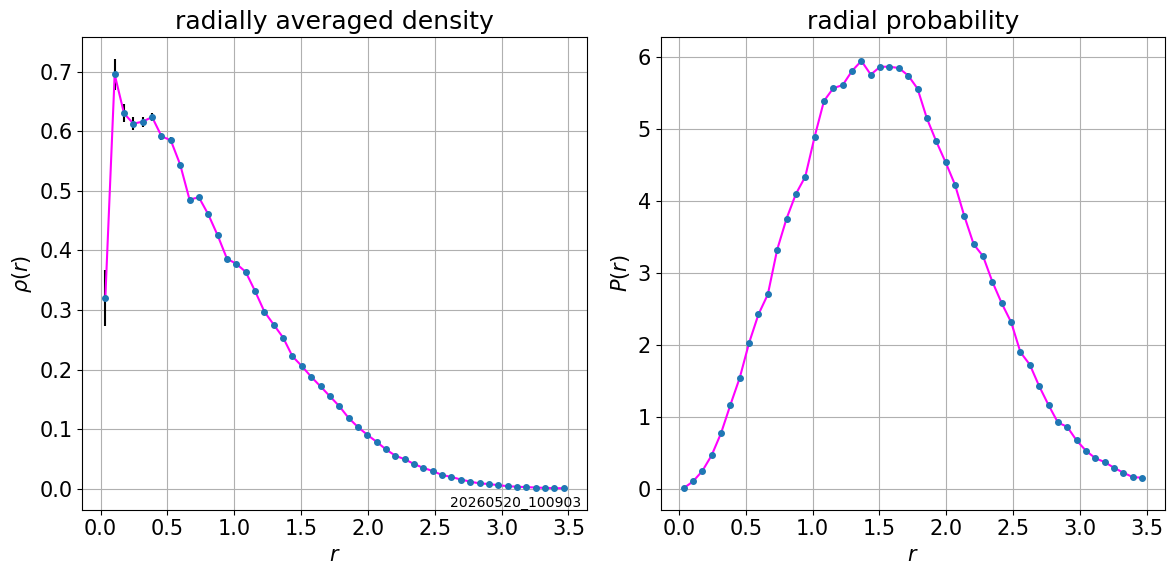

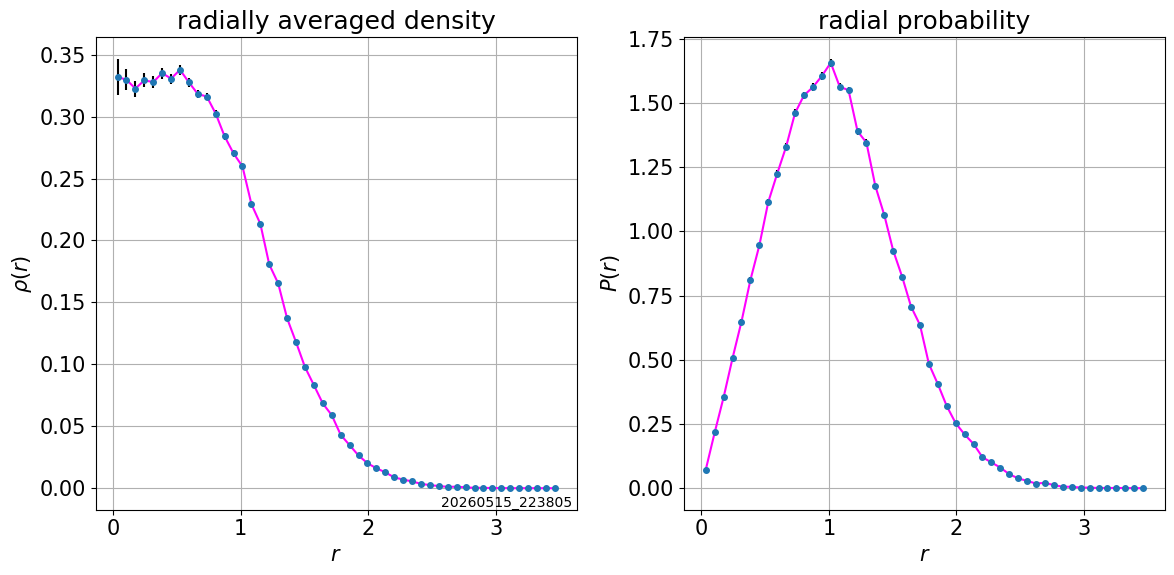

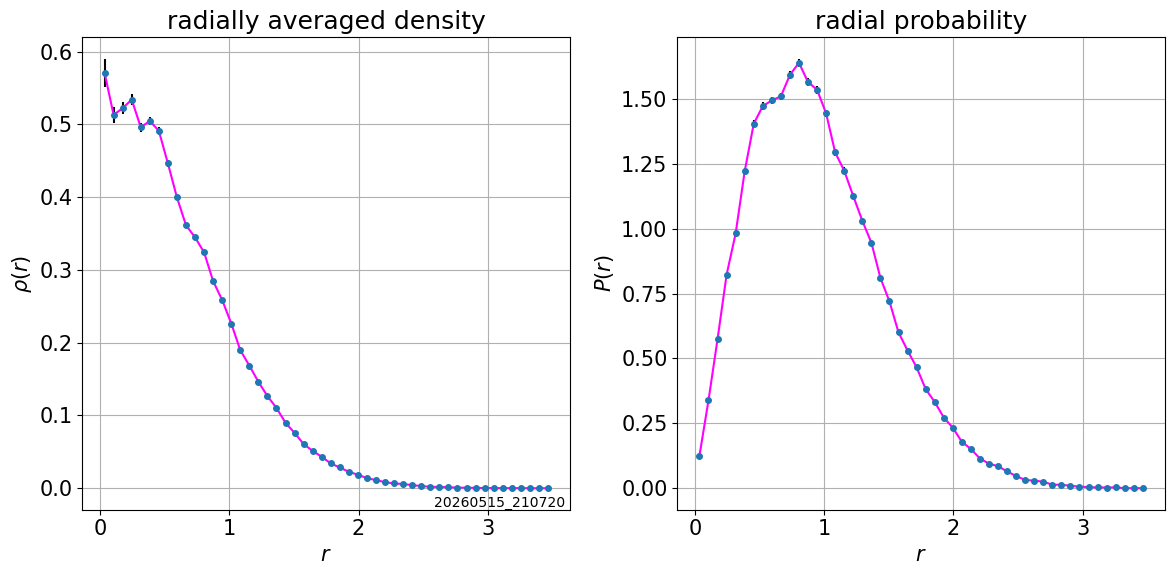

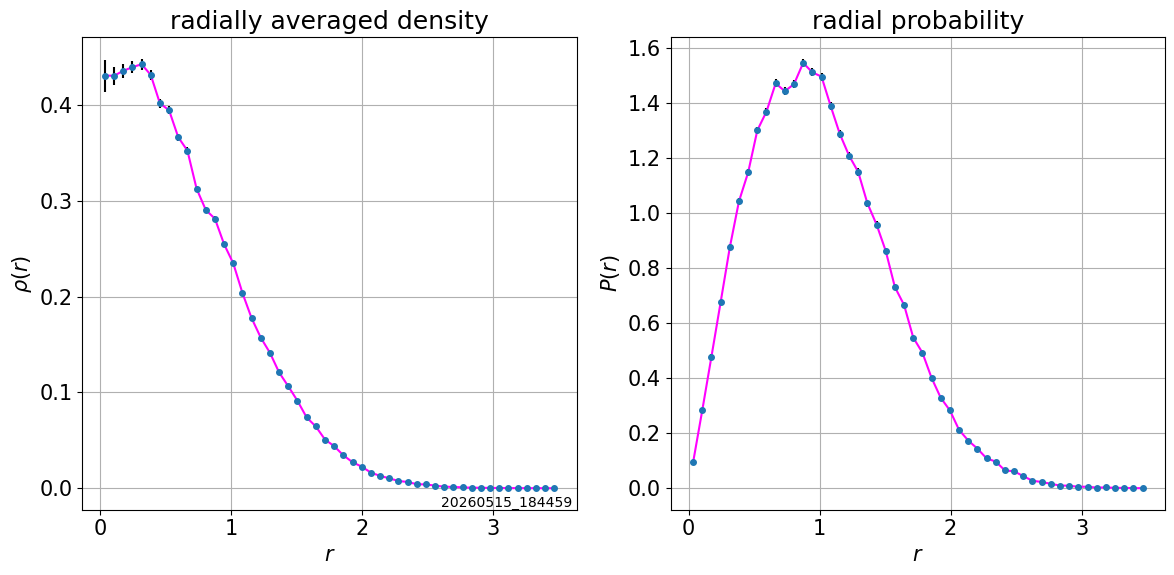

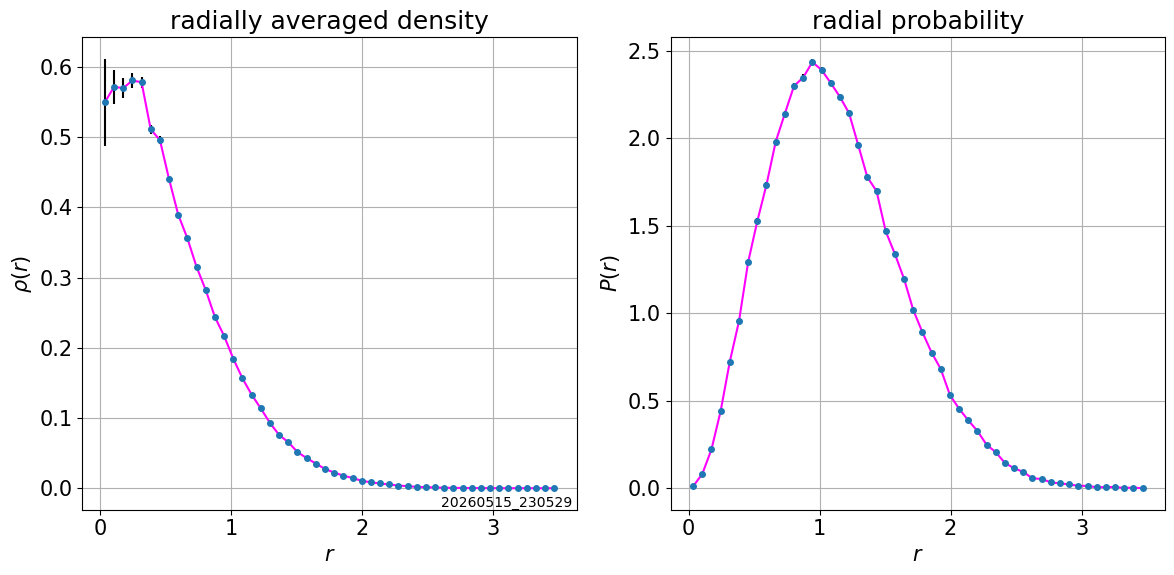

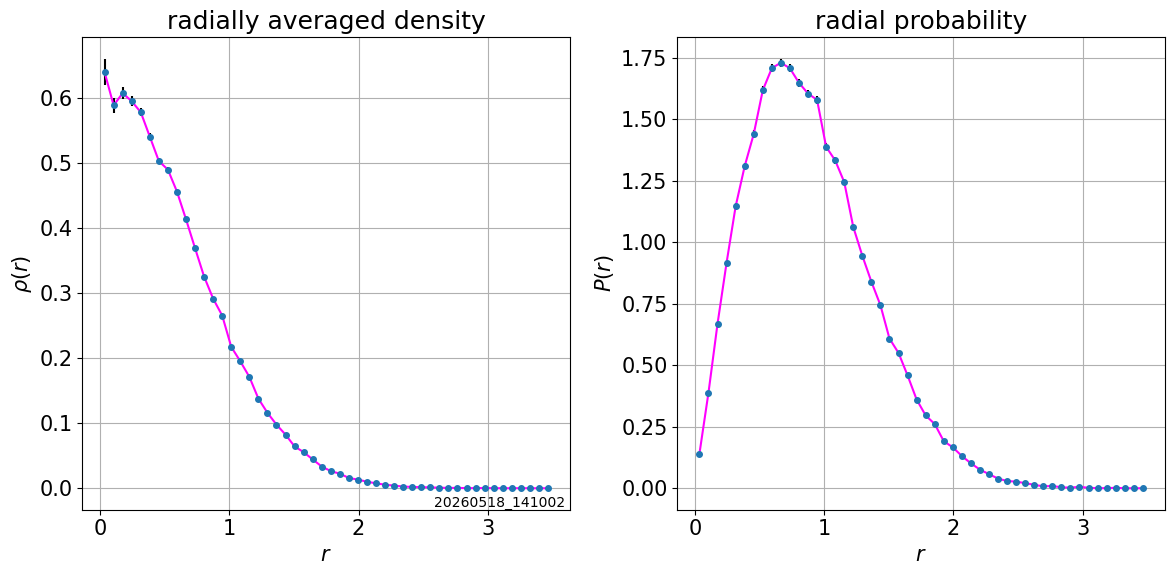

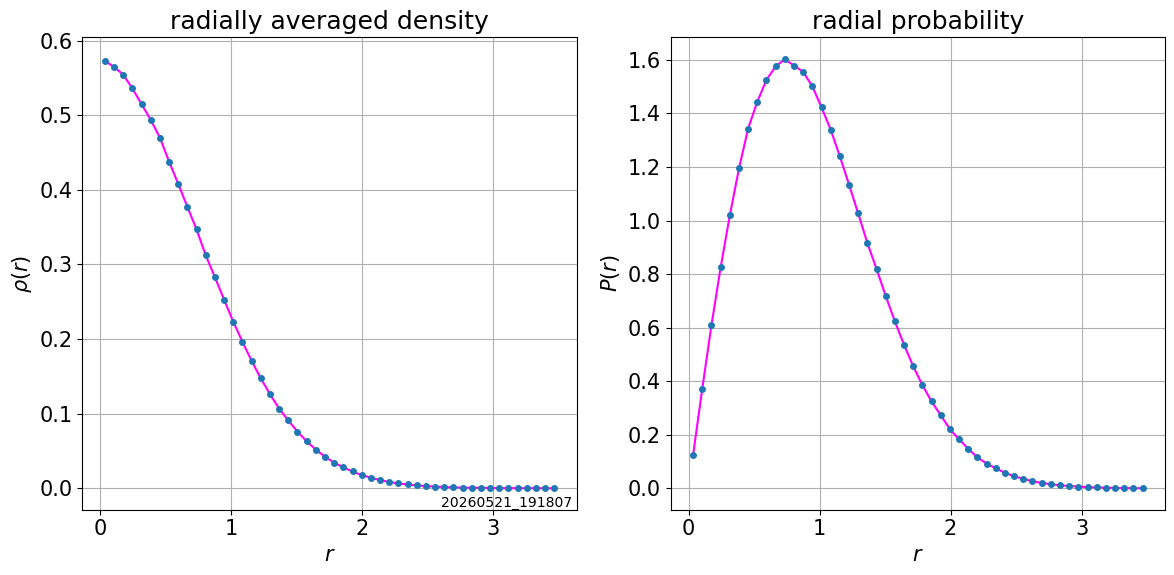

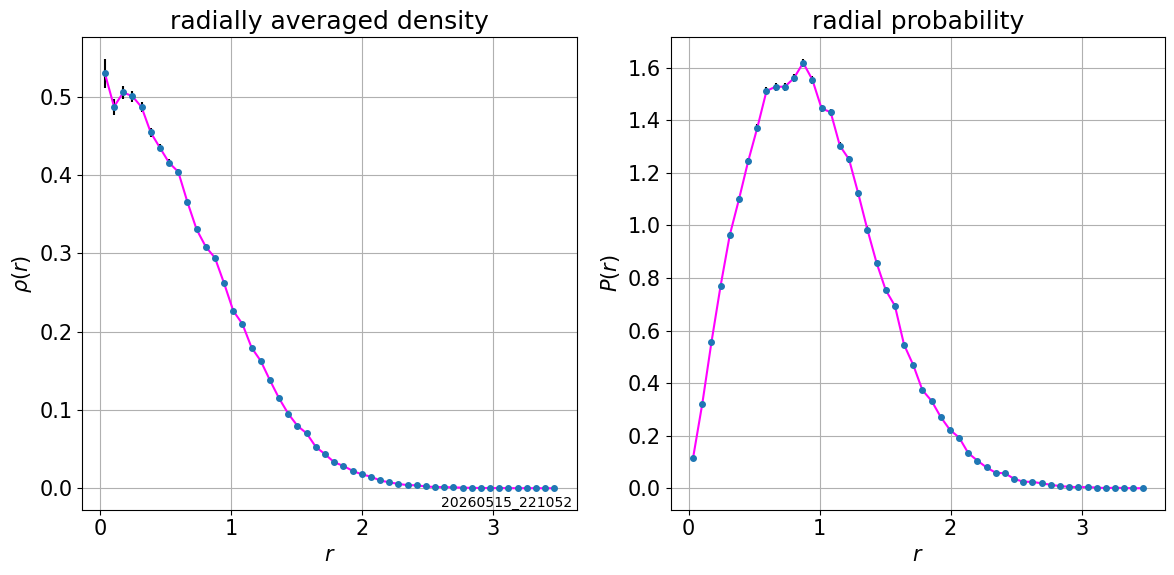

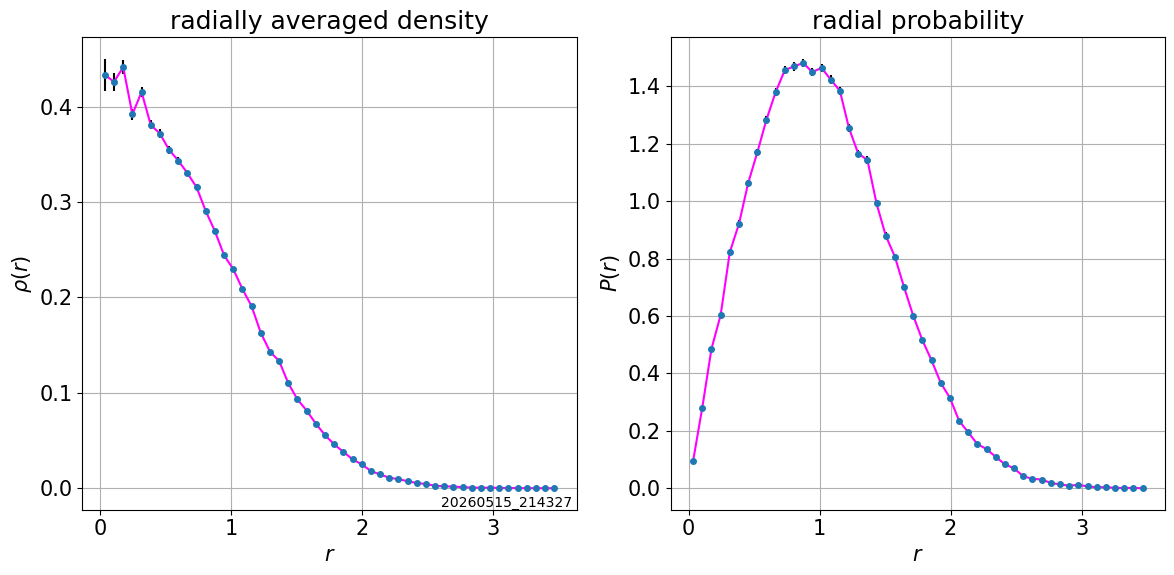

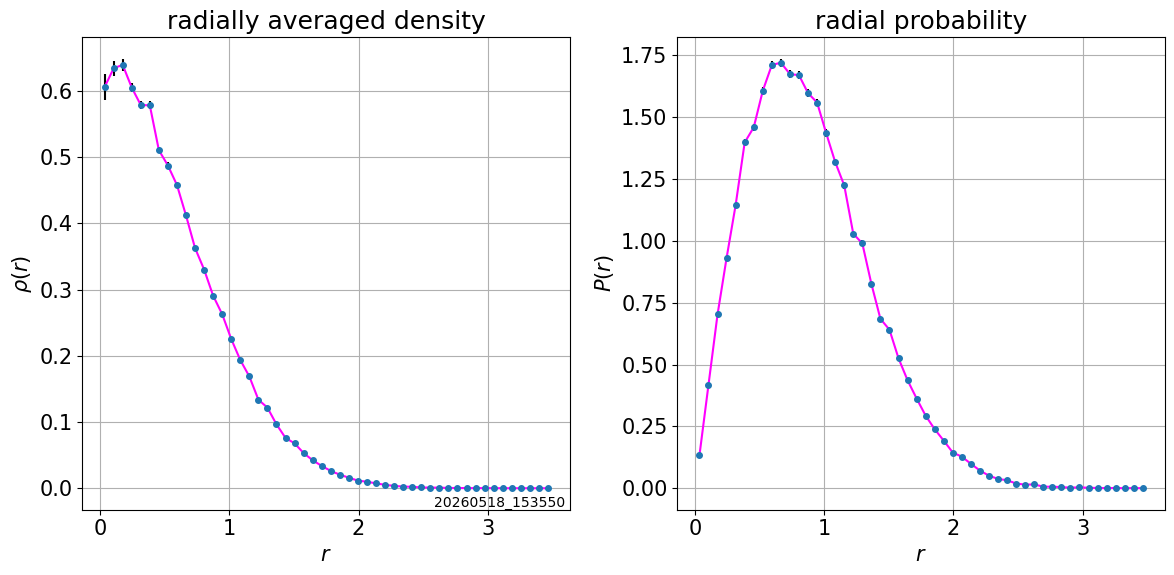

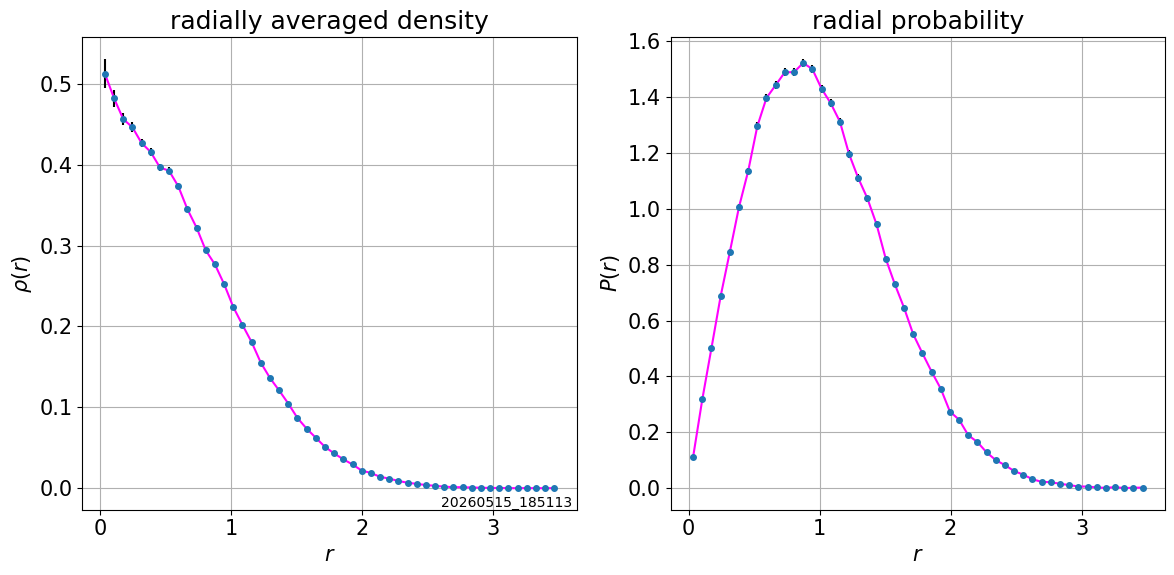

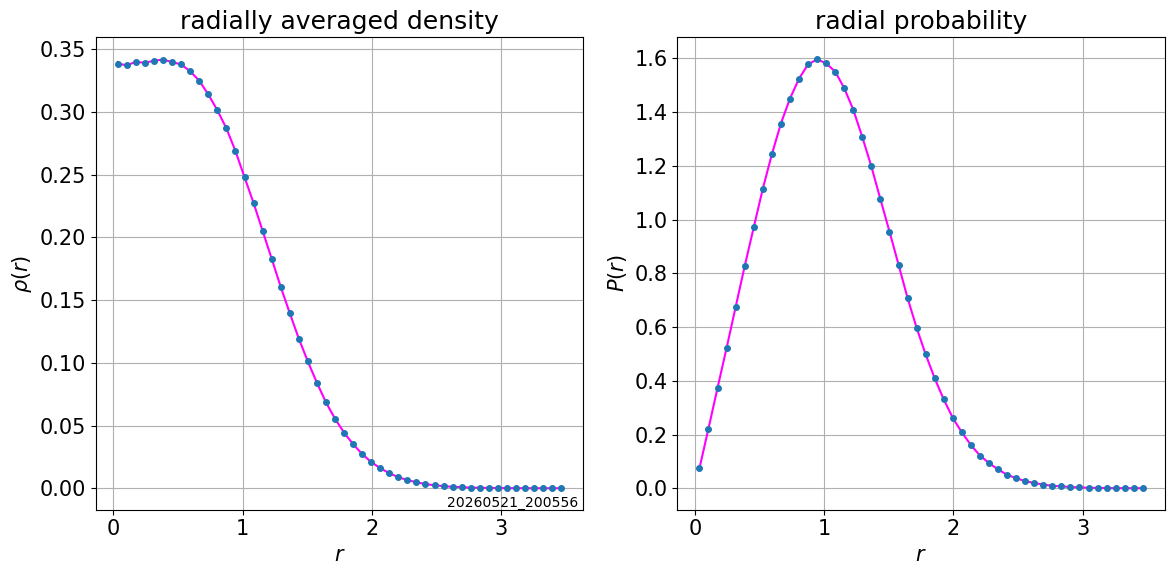

In [74]:
%matplotlib inline

def volume_hshpere(r, dim):
    return 2 * np.pi**(dim/2) / sp.special.gamma(dim/2) * r**(dim-1)

fdir = "./logs_OBD"
directory = os.fsencode(fdir)
for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        fname = filename
        totfname = f"{fdir}/{fname}"

        dim = 3
        r, rho, drho, p, dp = np.loadtxt(totfname, delimiter=',', unpack=True)

        fig = plt.figure(figsize=(12, 6))
        gs = fig.add_gridspec(1, 2)

        ax = fig.add_subplot(gs[0, 0])
        ax.errorbar(r, y=rho, yerr=drho, color='magenta', ecolor='black',
                    marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
        ax.set_title(r"radially averaged density")
        ax.set_ylabel(r"$\rho(r)$")
        ax.set_xlabel(r"$r$")
        ax.text(0.99, 0, fname[4:len(fname)-4], transform=ax.transAxes, fontsize=10, ha="right", va="bottom")

        ax = fig.add_subplot(gs[0, 1])
        ax.errorbar(r, y=p, yerr=dp, color='magenta', ecolor='black',
                    marker='.', markersize=8, linestyle='-', mfc="tab:blue", mec="tab:blue")
        # ax.errorbar(r, y=rad_rho, yerr=drad_rho, color='red', ecolor='black',
        #             marker='x', markersize=8, linestyle='--', mfc="tab:green", mec="tab:green", alpha=0.4)
        ax.set_title(r"radial probability")
        ax.set_ylabel(r"$P(r)$")
        ax.set_xlabel(r"$r$")
        fig.tight_layout()
        md = readmetadata(f"logs/{fname[:-4]}.log")
        print(md)
        fig.savefig(f"figs_NN/OBD_{fname[4:len(fname)-4]}.png", dpi=300, metadata=md)

nPreTrain = 38
nTrain = 250
final E = 3.036 ± 0.002
nPreTrain = 30
nTrain = 250
final E = 3.026 ± 0.005
nPreTrain = 20
nTrain = 250
final E = 3.057 ± 0.003


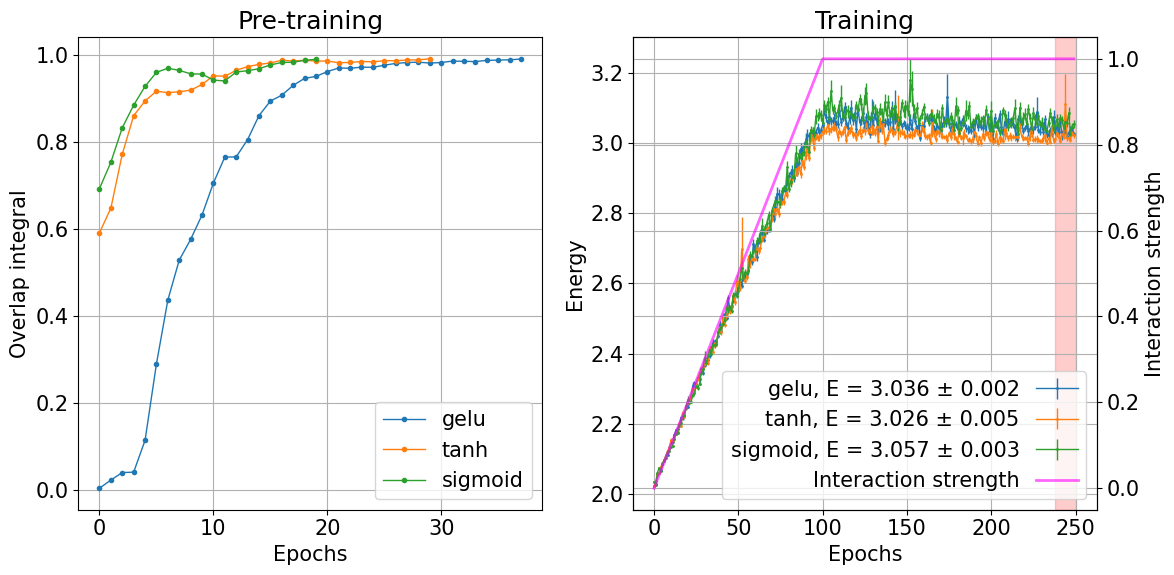

In [112]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax0.set_ylabel("Overlap integral")
ax0.set_xlabel("Epochs")
ax0.set_title("Pre-training")

ax1 = fig.add_subplot(gs[0, 1])
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax1.set_title("Training")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Energy")

fdir = "./logs_NN"
fname = ["run_20260515_210720.csv", "run_20260515_214327.csv", "run_20260515_223805.csv"]
label = ["gelu", "tanh", "sigmoid"]
line1 = [0, 0, 0]

for i in range(len(fname)):
    totfname = f"{fdir}/{fname[i]}"
    nPreTrain = 0
    nTrain = 0
    sw = False
    with open(file=totfname) as logfile:
        for line in logfile:
            if len(line) > 1 and line[0] != '#':
                if sw:
                    nTrain += 1
                else:
                    nPreTrain += 1
            elif len(line) == 1:
                sw = True
    print(f"nPreTrain = {nPreTrain}")
    print(f"nTrain = {nTrain}")
        
    K = np.loadtxt(totfname, delimiter=',', skiprows=2, max_rows=nPreTrain, usecols=0)
    training = np.loadtxt(totfname, delimiter=',', skiprows=2+nPreTrain+3, max_rows=nTrain, usecols=range(4))
    energy = training[:, 0]
    variance = training[:, 1]
    error = training[:, 2]
    strength = training[:, 3]
    numberofsubE = int(0.05 * nTrain)
    subE = energy[energy.size - numberofsubE:]
    meanE, dmeanE = np.mean(subE), np.std(subE) / np.sqrt(30)
    print(f"final E = {valErr_format(meanE, dmeanE)}")

    ax0.errorbar(np.arange(0, nPreTrain), K, ls='-', linewidth=1, marker='.', markersize=6, label=label[i])

    line1[i] = ax1.errorbar(np.arange(0, nTrain), energy, error, ls='-', linewidth=1, marker='.', markersize=2, label=f"{label[i]}, E = {valErr_format(meanE, dmeanE)}")
    # finalE = ax1.hlines(meanE, nTrain - subE.size, nTrain, ls='-', linewidth=3, color="red", label=f"mean final E = {valErr_format(meanE, dmeanE)}", zorder=3)
ax1.axvspan(nTrain - subE.size, nTrain, color="red", alpha=0.2)
ax0.legend()
ax2 = ax1.twinx()
ax2.set_ylabel("Interaction strength")
line2 = ax2.errorbar(np.arange(0, nTrain), strength, ls='-', linewidth=2, color='magenta', alpha=0.6, label='Interaction strength')
lines = [*line1, line2]
labels = [l.get_label() for l in lines]
leg = ax2.legend(lines, labels, loc='best', markerfirst=False)
leg.set_zorder(10)

fig.tight_layout()
fig.savefig(f"figs_NN/optimization_activ_func.png", dpi=300)

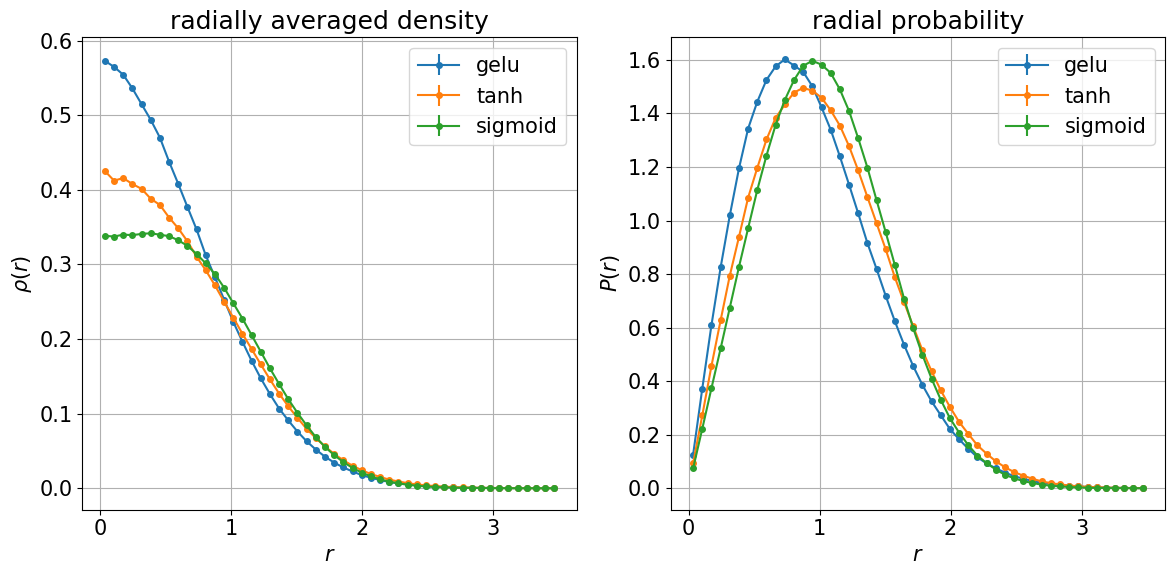

In [ ]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_title(r"radially averaged density")
ax0.set_ylabel(r"$\rho(r)$")
ax0.set_xlabel(r"$r$")

ax1 = fig.add_subplot(gs[0, 1])
ax1.set_title(r"radial probability")
ax1.set_ylabel(r"$P(r)$")
ax1.set_xlabel(r"$r$")

fdir = "./logs_OBD"
directory = os.fsencode(fdir)
fname = ["run_20260521_191807.csv", "run_20260521_195341.csv", "run_20260521_200556.csv"]
label = ["gelu", "tanh", "sigmoid"]

for i in range(len(fname)):
    totfname = f"{fdir}/{fname[i]}"

    dim = 3
    r, rho, drho, p, dp = np.loadtxt(totfname, delimiter=',', unpack=True)
    ax0.errorbar(r, y=rho, yerr=drho, marker='.', markersize=8, linestyle='-', label=label[i])
    ax1.errorbar(r, y=p, yerr=dp, marker='.', markersize=8, linestyle='-', label=label[i])

ax0.legend()
ax1.legend()
fig.tight_layout()
fig.savefig(f"figs_NN/OBD_activ_func.png", dpi=300)